In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Advertise.xlsx to Advertise.xlsx


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_excel("Advertise.xlsx")

df.head(10)

,T.V,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9
5,8.7,7.2
6,57.5,11.8
7,120.2,13.2
8,8.6,4.8
9,199.8,10.6


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

Dataset Shape: (10, 2)

Column Names:
Index(['T.V', 'Sales'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   T.V     10 non-null     float64
 1   Sales   10 non-null     float64
dtypes: float64(2)
memory usage: 292.0 bytes
None


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
T.V      0
Sales    0
dtype: int64


In [ ]:
X = df[['T.V']]
y = df['Sales']

print("Independent Variable (X):")
print(X)

print("\nDependent Variable (y):")
print(y)

Independent Variable (X):
     T.V
0  230.1
1   44.5
2   17.2
3  151.5
4  180.8
5    8.7
6   57.5
7  120.2
8    8.6
9  199.8

Dependent Variable (y):
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
5     7.2
6    11.8
7    13.2
8     4.8
9    10.6
Name: Sales, dtype: float64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8
Testing samples: 2


In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [ ]:
print("Intercept (β0):", model.intercept_)
print("Coefficient (β1):", model.coef_[0])

print(
    f"\nRegression Equation: "
    f"Sales = {model.intercept_:.4f} + "
    f"{model.coef_[0]:.4f} × TV"
)

Intercept (β0): 8.187926896645866
Coefficient (β1): 0.0415164473253604

Regression Equation: Sales = 8.1879 + 0.0415 × TV


In [ ]:
y_pred = model.predict(X_test)

print("Actual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)

Actual Values:
[ 4.8 10.4]

Predicted Values:
[ 8.54496834 10.0354088 ]


In [ ]:
comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

comparison

,Actual Sales,Predicted Sales
0,4.8,8.544968
1,10.4,10.035409


In [ ]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 7.078857318049599
Root Mean Squared Error (RMSE): 2.660612207378144
R² Score: 0.09708452575897986


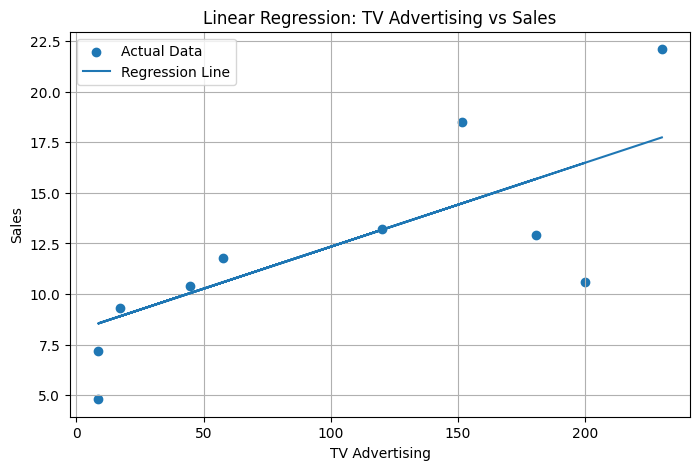

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y, label='Actual Data')

plt.plot(
    X,
    model.predict(X),
    label='Regression Line'
)

plt.xlabel('TV Advertising')
plt.ylabel('Sales')
plt.title('Linear Regression: TV Advertising vs Sales')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
residuals = y_pred - y_test

print("Residuals:")
print(residuals.values)

Residuals:
[ 3.74496834 -0.3645912 ]


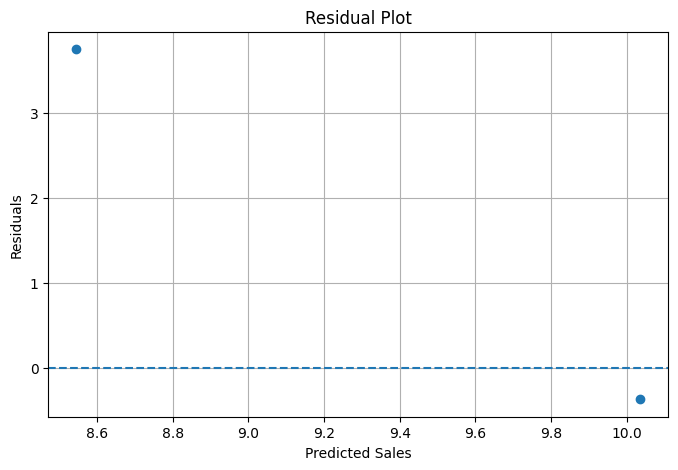

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.grid(True)

plt.show()

In [ ]:
new_data = pd.DataFrame({'T.V': [150]})

prediction = model.predict(new_data)

print("TV Advertising:", 150)
print("Predicted Sales:", prediction[0])

TV Advertising: 150
Predicted Sales: 14.415393995449927
